## Práctica 5: Análisis frecuencial

Daniel Iván Lozano Simanca<br>
Samuel Ochoa Alzate

En la siguiente practica hacemos uso de las herramientas en las correspondientes librerías de Python para la creación, manejo, filtrado y análisis en frecuencia de diferentes señales. Se trabajó en esta práctica con señales generadas por numpy y a lo último, se utilizaron señales existentes en archivos .mat. 

Para 4.1, se definió la frecuencia de muestreo utilizando el teorema de Nyquist, utilizando nuestra frecuencia máxima como 160 Hz. Además, por el MCD, se definió el periodo de la señal generada como 1/40 s.

81


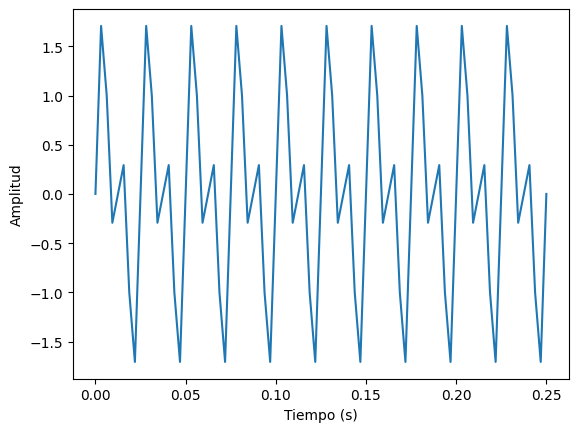

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

f1 = 40 #Hz
f2 = 80 #Hz
f3 = 160 #Hz

T = 1/40 #s
f_sampling = 160*2 #Hz
n = T/(1/f_sampling) #samples

tf = 10*T #s

t = np.arange(0, tf + 1/f_sampling, 1/f_sampling)

print(len(t))
signal = np.sin(2*np.pi*f1*t) + np.sin(2*np.pi*f2*t) + np.sin(2*np.pi*f3*t)
plt.plot(t, signal)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()

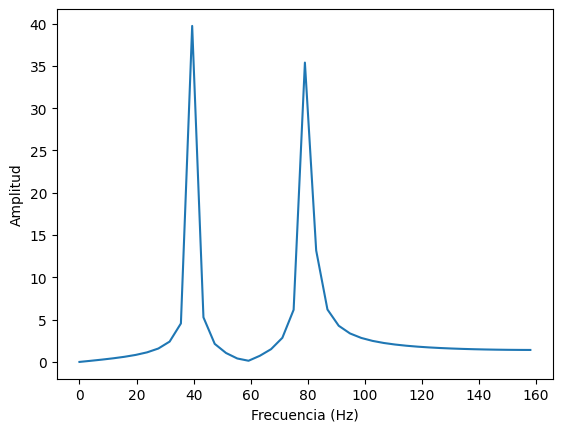

Picos en [39.50617284 79.01234568] [Hz]


In [2]:
signal_fft = np.fft.fft(signal)
n_mitad = int(np.ceil(len(signal_fft)/2))
freq_mitad = np.arange(0, n_mitad) * f_sampling / len(signal_fft)
signalfft_mitad = signal_fft[0:n_mitad]

plt.plot(freq_mitad, abs(signalfft_mitad))
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.show()

peaks, _ = find_peaks(abs(signalfft_mitad))
x_peaks = freq_mitad[peaks]

print(f'Picos en {x_peaks} [Hz]')

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


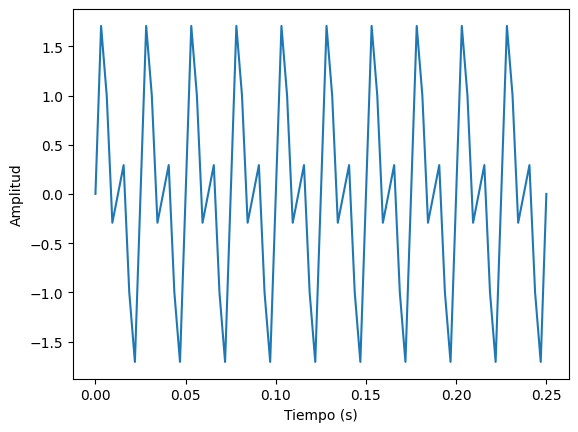

In [3]:
#IFFT
signal_ifft = np.fft.ifft(signal_fft)
plt.plot(t, signal_ifft)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15332\3741771931.py:4: ComplexWarning: Casting complex values to real discards the imaginary part
  F2[9:13] = F1[9:13]


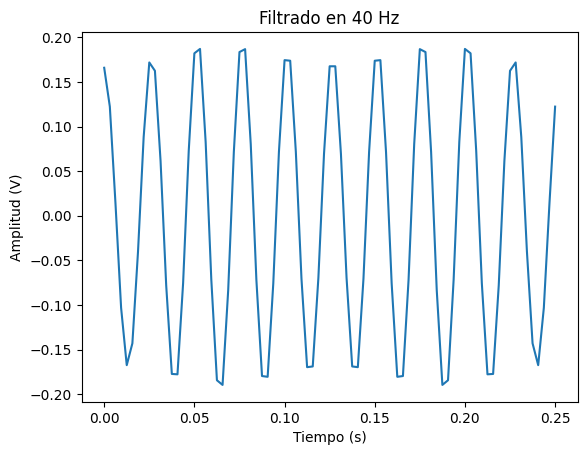

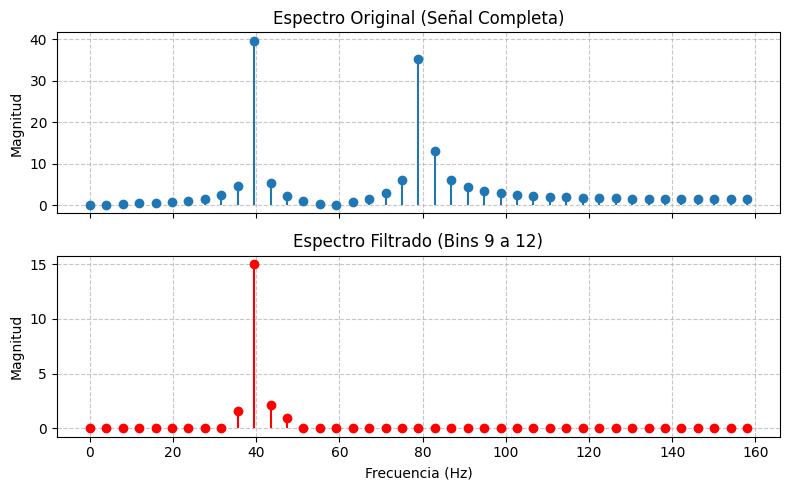

In [4]:
#Filtrando en 40Hz
F1 = np.fft.fft(signal)
F2 = np.zeros((len(F1)))
F2[9:13] = F1[9:13]
signal_r = np.fft.ifft(F2)
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(t, np.real(signal_r))
ax.set(title='Filtrado en 40 Hz',xlabel='Tiempo (s)', ylabel='Amplitud (V)')
plt.show()

F2_mitad = F2[0:n_mitad]

fig_spec, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

# Original
ax_top.stem(freq_mitad, np.abs(signalfft_mitad), basefmt=" ")
ax_top.set_title('Espectro Original (Señal Completa)')
ax_top.set_ylabel('Magnitud')
ax_top.grid(True, linestyle='--', alpha=0.7)

# Filtrada
ax_bot.stem(freq_mitad, np.abs(F2_mitad), linefmt='r', markerfmt='ro', basefmt=" ")
ax_bot.set_title('Espectro Filtrado (Bins 9 a 12)')
ax_bot.set_xlabel('Frecuencia (Hz)')
ax_bot.set_ylabel('Magnitud')
ax_bot.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Podemos ver que a la señal se le aplicó un filtro Band-Pass centrado en ~ 40 Hz.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15332\407539768.py:4: ComplexWarning: Casting complex values to real discards the imaginary part
  F_80[19:23] = F1[19:23]


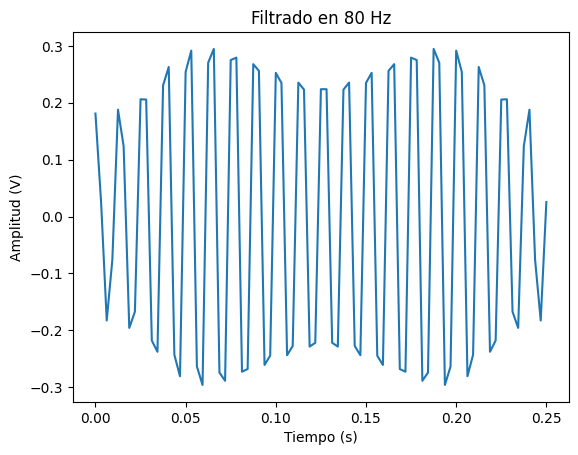

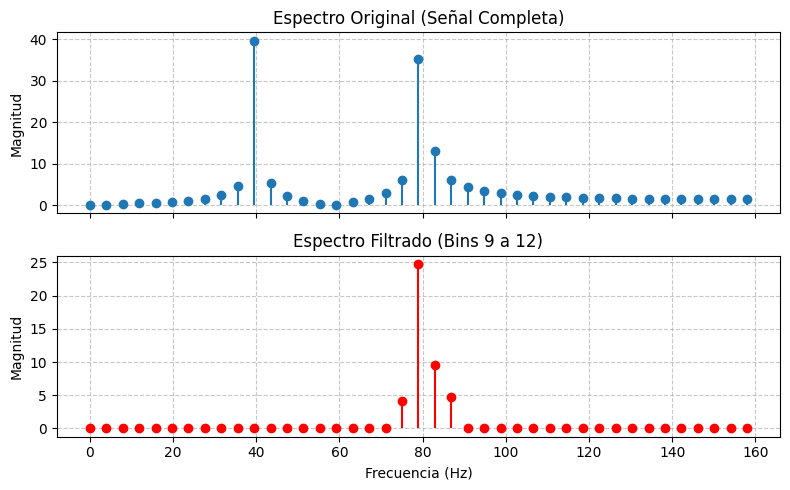

In [7]:
#Filtrando en 80Hz
#F1 = np.fft.fft(signal)
F_80 = np.zeros((len(F1)))
F_80[19:23] = F1[19:23]
signal_80 = np.fft.ifft(F_80)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(t, np.real(signal_80))
ax.set(title='Filtrado en 80 Hz', xlabel='Tiempo (s)', ylabel='Amplitud (V)')
plt.show()

F_80_mitad = F_80[0:n_mitad]
fig_spec, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

# Original
ax_top.stem(freq_mitad, np.abs(signalfft_mitad), basefmt=" ")
ax_top.set_title('Espectro Original (Señal Completa)')
ax_top.set_ylabel('Magnitud')
ax_top.grid(True, linestyle='--', alpha=0.7)

# Filtrada
ax_bot.stem(freq_mitad, np.abs(F_80_mitad), linefmt='r', markerfmt='ro', basefmt=" ")
ax_bot.set_title('Espectro Filtrado (Bins 9 a 12)')
ax_bot.set_xlabel('Frecuencia (Hz)')
ax_bot.set_ylabel('Magnitud')
ax_bot.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15332\3622001625.py:4: ComplexWarning: Casting complex values to real discards the imaginary part
  F_160[39:43] = F1[39:43]


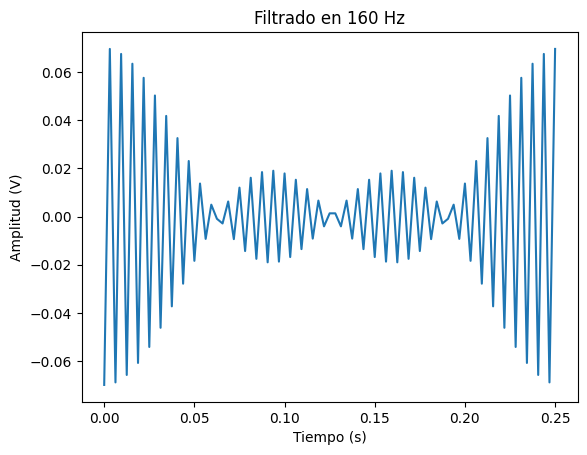

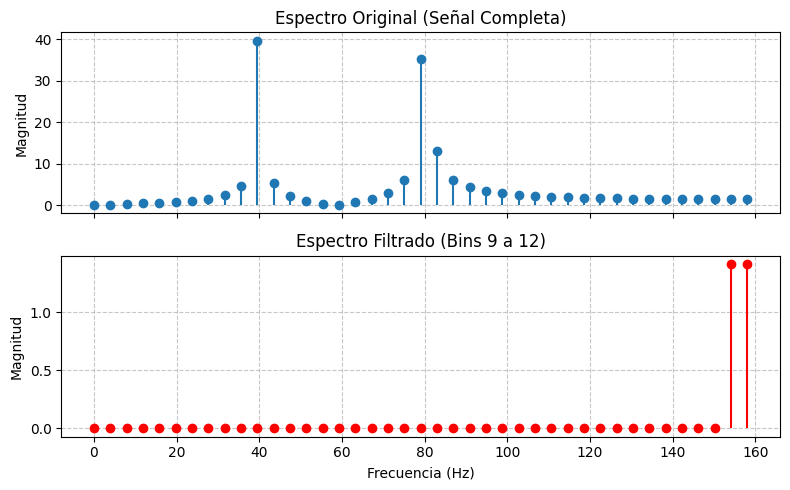

In [8]:
#Filtrando en 160Hz
#F1 = np.fft.fft(signal)
F_160 = np.zeros((len(F1)))
F_160[39:43] = F1[39:43]
signal_160 = np.fft.ifft(F_160)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(t, np.real(signal_160))
ax.set(title='Filtrado en 160 Hz', xlabel='Tiempo (s)', ylabel='Amplitud (V)')
plt.show()

F_160_mitad = F_160[0:n_mitad]
fig_spec, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

# Original
ax_top.stem(freq_mitad, np.abs(signalfft_mitad), basefmt=" ")
ax_top.set_title('Espectro Original (Señal Completa)')
ax_top.set_ylabel('Magnitud')
ax_top.grid(True, linestyle='--', alpha=0.7)

# Filtrada
ax_bot.stem(freq_mitad, np.abs(F_160_mitad), linefmt='r', markerfmt='ro', basefmt=" ")
ax_bot.set_title('Espectro Filtrado (Bins 9 a 12)')
ax_bot.set_xlabel('Frecuencia (Hz)')
ax_bot.set_ylabel('Magnitud')
ax_bot.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

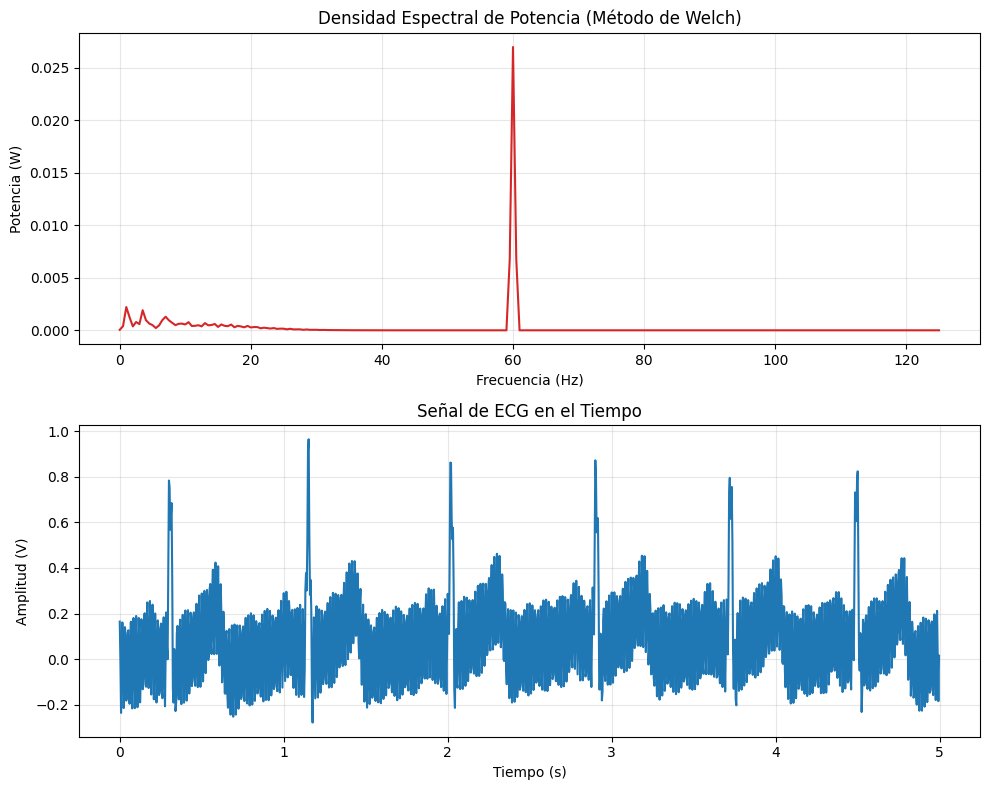

In [53]:
from scipy.io import loadmat
from scipy.signal import welch 

data = loadmat('senecg.mat')
signal_ecg = data['ECG'].flatten()

fs = 250 #Hz

t = np.arange(0, len(signal_ecg)/fs, 1/fs)
n_ventana = 500 #num de muestras para la ventana
n_overlap = int(n_ventana/2)
freqs, Pxx = welch(signal_ecg, 
                   fs=fs, 
                   window='hann', 
                   nperseg=n_ventana, 
                   noverlap=n_overlap)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))


ax1.plot(freqs, Pxx, color='tab:red')
ax1.set_title('Densidad Espectral de Potencia (Método de Welch)')
ax1.set_xlabel('Frecuencia (Hz)')
ax1.set_ylabel('Potencia (W)')
ax1.grid(True, alpha=0.3)

ax2.plot(t, signal_ecg, color='tab:blue')
ax2.set_title('Señal de ECG en el Tiempo')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Amplitud (V)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [48]:
trans_ecg = np.fft.fft(signal_ecg)

n_mitadECG = int(np.ceil(len(trans_ecg)/2))
freq_mitad = np.arange(0, n_mitadECG) * fs / len(trans_ecg)
transECG_mitad = trans_ecg[0:n_mitadECG]

peaks, _ = find_peaks(abs(transECG_mitad), height=40)
x_peaks = freq_mitad[peaks]

print(f'Picos en {x_peaks} [Hz]')
print(peaks)

Picos en [60.] [Hz]
[300]


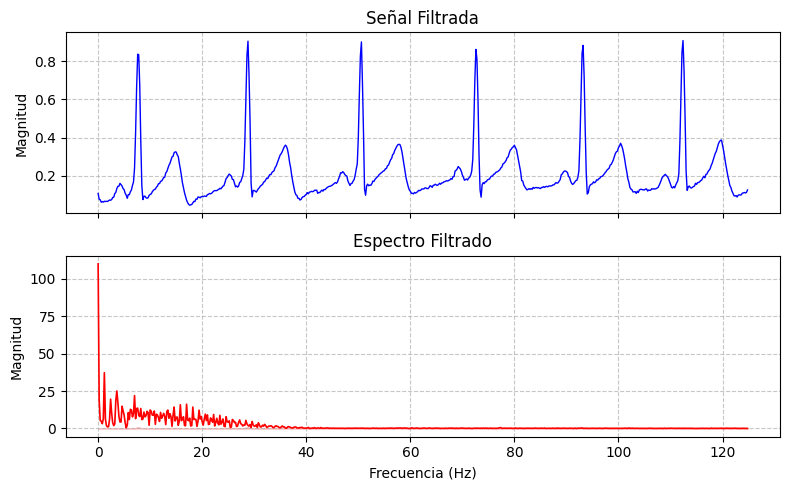

In [ ]:
#Filtrando en 40Hz
signalZeros = np.zeros((len(transECG_mitad)))
#signalZeros[9:13] = transECG_mitad[9:13]
transECG_mitad[299:301] = signalZeros[299:301]
signalECG_r = np.fft.ifft(transECG_mitad)

fig_spec, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

#LA señal filtrada en 60 Hz
ax_top.plot(freq_mitad, np.abs(signalECG_r), color='blue', linewidth=1)
ax_top.set_title('Señal Filtrada')
ax_top.set_ylabel('Magnitud')
ax_top.grid(True, linestyle='--', alpha=0.7)

#Espectro de la señal filtrada
ax_bot.plot(freq_mitad, np.abs(transECG_mitad), color='red', linewidth=1.2)
ax_bot.set_title('Espectro Filtrado')
ax_bot.set_xlabel('Frecuencia (Hz)')
ax_bot.set_ylabel('Magnitud')
ax_bot.grid(True, linestyle='--', alpha=0.7)

ax_bot.fill_between(freq_mitad, np.abs(signalECG_r), color='red', alpha=0.2)

plt.tight_layout()
plt.show()